# Cross-generation similarity comparison (aigen vs nogen vs plain)

Compares **feedback / generation types against each other** on the same similarity metrics.
This is the complement to `within_gen_similarity_plotting.ipynb` (which compares *tasks*
within one generation). Here the comparison axis is **generation**.

Add generations to `GENS` as their data lands — `plain` is forward-compatible and needs no
code change. `config.load` tags every row with `condition` / `generation` / `task`, and
`config.GROUPS_BY_GEN` already lists the slugs per generation.

**Two views**
1. **Faceted by task** — one panel per perception / immediate / delay; within each panel one
   mean +/- 95% CI line per generation over attempts 1-3.
2. **One point per condition** — every (generation x task) condition collapsed across
   attempts/participants to a single mean +/- 95% CI point, so all conditions rank at a glance.

**Conventions** (identical to the within-generation notebook)
- Always plot **similarity**, never distance: `clip_similarity = 1 - clip_cosine_distance`,
  `vgg_similarity = 1 - vgg_fc7_distance`; `clip_vis_text_similarity` is already a similarity.
- One fixed, colorblind-safe color per **generation**, reused in every figure.

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find project root (the dir containing config.py) regardless of where the notebook sits.
project_root = Path.cwd()
while not (project_root / "config.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config
print("project root:", project_root)

project root: /mnt/hdd/anatkorol/Imagination_in_translation


In [8]:
# --- Which generations to compare. Add "plain" once its trials_final_sim.csv exists. ---
GENS = ["aigen", "nogen", "plain"]

slugs = [c for g in GENS for c in config.GROUPS_BY_GEN[g]]
df = config.load(slugs, sim=True)              # tagged with condition / generation / task
assert not df.empty, f"no trials_final_sim.csv found for any of {slugs}"

# Keep only generations that actually loaded (skips any without data yet).
GEN_ORDER = [g for g in ["aigen", "nogen", "plain"] if g in set(df["generation"])]

GRAPHS = config.ROOT / "analysis" / "outputs" / config.DATASET / "combined" / "graphs"
GRAPHS.mkdir(parents=True, exist_ok=True)
print("generations loaded:", GEN_ORDER, "-> saving figures to:", GRAPHS)
df.groupby(["generation", "task"]).size().unstack("task")

generations loaded: ['aigen', 'nogen', 'plain'] -> saving figures to: /mnt/hdd/anatkorol/Imagination_in_translation/analysis/outputs/Full_experiment/combined/graphs


task,delay,immediate,perception
generation,,,
aigen,297,327,279
nogen,222,288,237
plain,96,114,121


In [9]:
# --- Derived columns: distances -> similarities (we ALWAYS plot similarity) ---
df["clip_similarity"] = 1 - df["clip_cosine_distance"]
df["vgg_similarity"]  = 1 - df["vgg_fc7_distance"]
# clip_vis_text_similarity is already a similarity (no inversion)
df["prompt_word_len"] = df["prompt"].astype(str).str.split().str.len()
df["attempt"] = df["attempt"].astype(int)

# Keep the latest record per (generation, task, uid, gt, attempt) in case of repeated slider moves.
df = (df.sort_values("ts")
        .groupby(["generation", "task", "uid", "gt", "attempt"], as_index=False, sort=False)
        .tail(1))

# Human participants only (mirrors the within-gen notebook's GPT split; no gpt rows today).
GPT_UID = "gpt-5"
df_ppt = df[df["uid"] != GPT_UID].copy()
print(f"human rows: {len(df_ppt)}")

human rows: 1981


In [10]:
# --- Style + fixed color maps (per generation, reused in every figure) ---
plt.style.use("seaborn-v0_8-whitegrid")

# Presentation-sized type and heavier lines: everything below scales with these,
# so bump FONT_SCALE / LINE_SCALE in one place to resize every figure in the notebook.
FONT_SCALE = 1.0   # multiply all font sizes
LINE_SCALE = 1.0   # multiply all line widths

def _f(pt):  return pt * FONT_SCALE
def _lw(w):  return w * LINE_SCALE

plt.rcParams.update({
    "figure.dpi":        110,
    "savefig.dpi":       300,
    "font.size":         _f(21),
    "axes.titlesize":    _f(27),
    "axes.labelsize":    _f(24),
    "xtick.labelsize":   _f(21),
    "ytick.labelsize":   _f(21),
    "legend.fontsize":   _f(21),
    "legend.title_fontsize": _f(22),
    "figure.titlesize":  _f(31),
    "axes.linewidth":    _lw(1.8),
    "grid.linewidth":    _lw(1.2),
    "lines.linewidth":   _lw(3.6),
    "lines.markersize":  11,
    "xtick.major.width": _lw(1.8),
    "ytick.major.width": _lw(1.8),
    "xtick.major.size":  7,
    "ytick.major.size":  7,
    "patch.linewidth":   _lw(1.4),
})

TASK_ORDER  = ["perception", "immediate", "delay"]
TASK_LABELS = {"perception": "Perception", "immediate": "Immediate memory", "delay": "Delayed memory"}
ATTEMPTS    = [1, 2, 3]

# Dark2: green / orange / purple — one fixed color per generation.
GEN_COLORS = {"aigen": "#1b9e77", "nogen": "#d95f02", "plain": "#7570b3"}
GEN_LABELS = {"aigen": "AI-gen (image)", "nogen": "No-gen (text)", "plain": "Plain (baseline)"}

def _legend_above(fig, handles, labels, y=0.90):
    """One horizontal legend for the whole figure, sitting between the suptitle and the panels."""
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, y),
               ncol=len(labels), frameon=False, handlelength=2.4,
               columnspacing=2.2, handletextpad=0.8)

# Similarity metrics: column -> axis label. y-limits autoscale so new data isn't clipped.
SIM_METRICS = {
    "subjective_score":         "Subjective similarity (0-100)",
    "clip_similarity":          "CLIP similarity",
    "vgg_similarity":           "VGG fc7 similarity",
    "clip_vis_text_similarity": "CLIP vision-text alignment",
}

# Prompt-effort metrics: not similarities, but comparable across generations the same way.
# Do participants write longer / more detailed prompts under one feedback type than another?
PROMPT_METRICS = {
    "prompt_word_len": "Prompt word count",
    "token_num":       "CLIP token count",
}

In [11]:
# --- Reusable helpers -------------------------------------------------------
def _ppt_attempt_means(data, metric):
    """Mean of `metric` per (generation, task, uid, attempt) — the per-participant points."""
    return (data.dropna(subset=[metric])
                .groupby(["generation", "task", "uid", "attempt"], as_index=False)[metric].mean())

def plot_generations_over_attempts_by_task(metric, ylabel, data=None, fname=None, ylim=None):
    """VIEW 1: one panel per task; within each panel one line per generation
    (mean +/- 95% bootstrap CI) over attempts 1-3."""
    data = df_ppt if data is None else data
    g = _ppt_attempt_means(data, metric)
    fig, axes = plt.subplots(1, len(TASK_ORDER), figsize=(7.2 * len(TASK_ORDER), 6.8),
                             sharey=True)
    axes = np.atleast_1d(axes)
    handles, labels = {}, []
    for i, (ax, task) in enumerate(zip(axes, TASK_ORDER)):
        for gen in GEN_ORDER:
            sub = g[(g["task"] == task) & (g["generation"] == gen)]
            if sub.empty:
                continue
            sns.lineplot(data=sub, x="attempt", y=metric, ax=ax, color=GEN_COLORS[gen],
                         lw=_lw(4.0), marker="o", markersize=13, markeredgewidth=0,
                         errorbar=("ci", 95), err_kws={"alpha": 0.20},
                         label=GEN_LABELS[gen])
            handles.setdefault(gen, ax.get_lines()[-1])
        ax.set_title(TASK_LABELS[task], pad=14)
        # x ticks are the bare attempt numbers; "Attempts" sits underneath as the axis label.
        ax.set_xticks(ATTEMPTS); ax.set_xticklabels([str(a) for a in ATTEMPTS])
        ax.set_xlabel("Attempts", labelpad=10)
        ax.set_ylabel(ylabel if i == 0 else "")
        ax.tick_params(width=_lw(1.8), length=7)
        if ax.get_legend() is not None:
            ax.get_legend().remove()  # replaced by the single figure-level legend
    if ylim is not None:
        axes[0].set_ylim(ylim)  # sharey=True propagates to all panels
    fig.suptitle(f"{ylabel} over attempts — generations compared by task", y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.86])
    gens = [g_ for g_ in GEN_ORDER if g_ in handles]
    _legend_above(fig, [handles[g_] for g_ in gens], [GEN_LABELS[g_] for g_ in gens], y=0.90)
    if fname:
        fig.savefig(GRAPHS / fname, dpi=300, bbox_inches="tight")
    plt.show()


## View 1 — generations over attempts, faceted by task
For each metric: one panel per task; within a panel, one line per generation (mean +/- 95% CI).
Shows whether the feedback type changes the attempt-1->3 trajectory, holding task fixed.

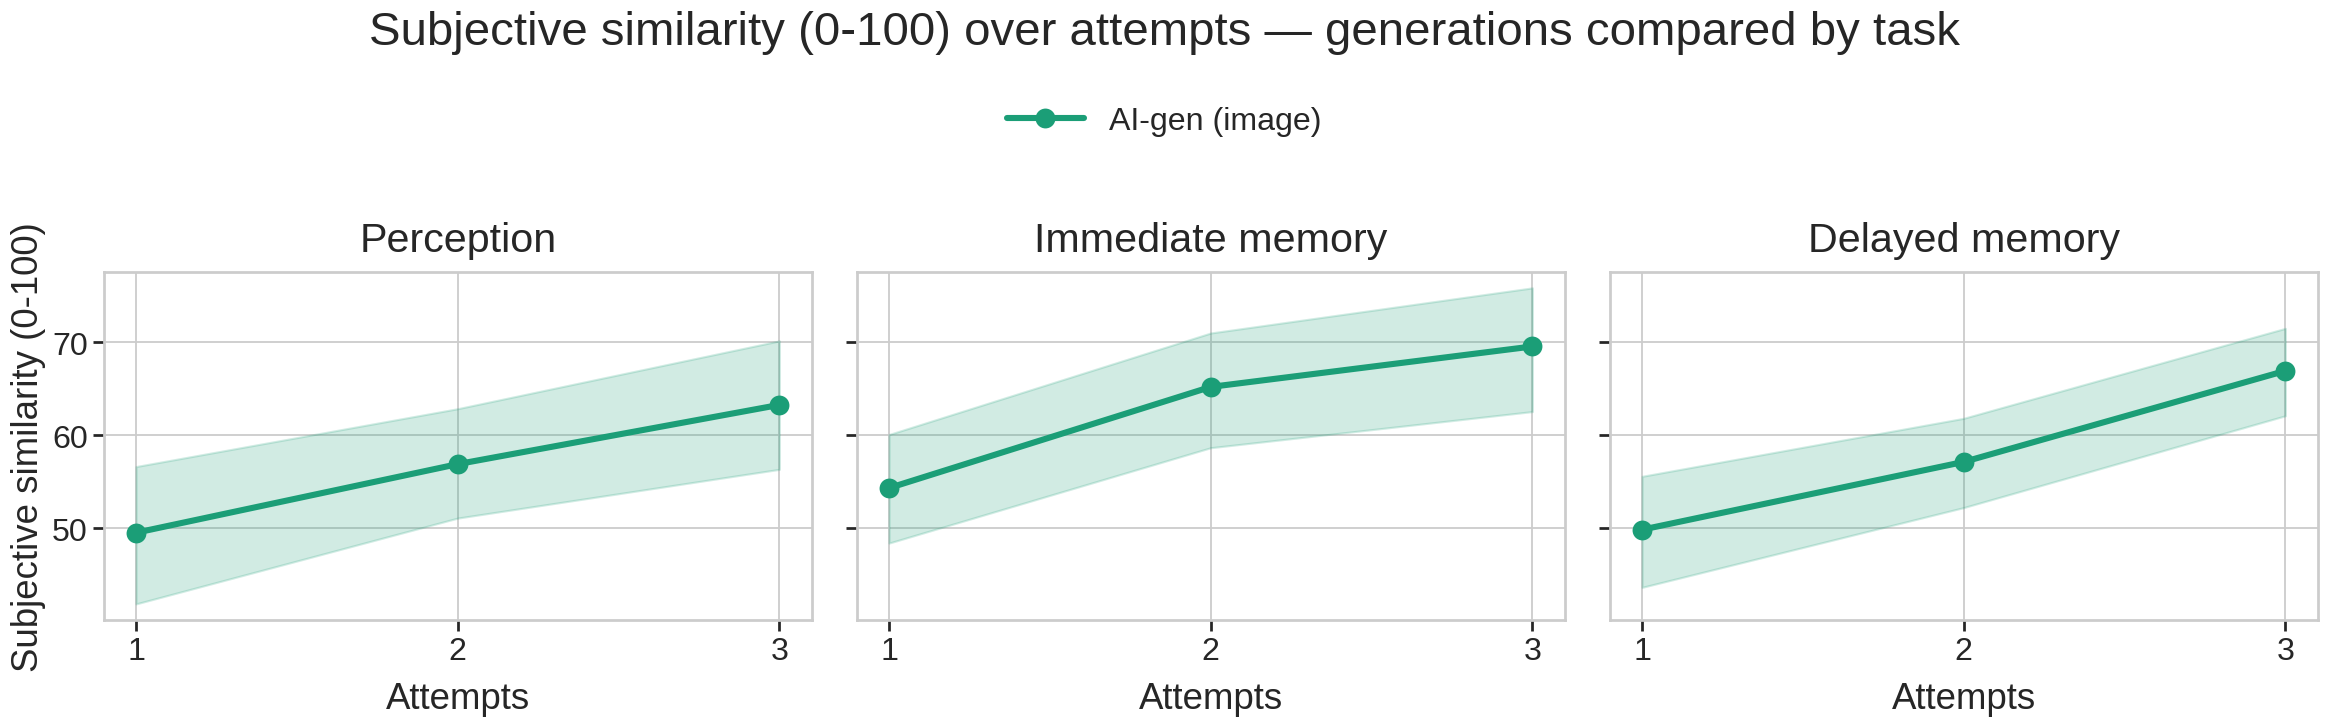

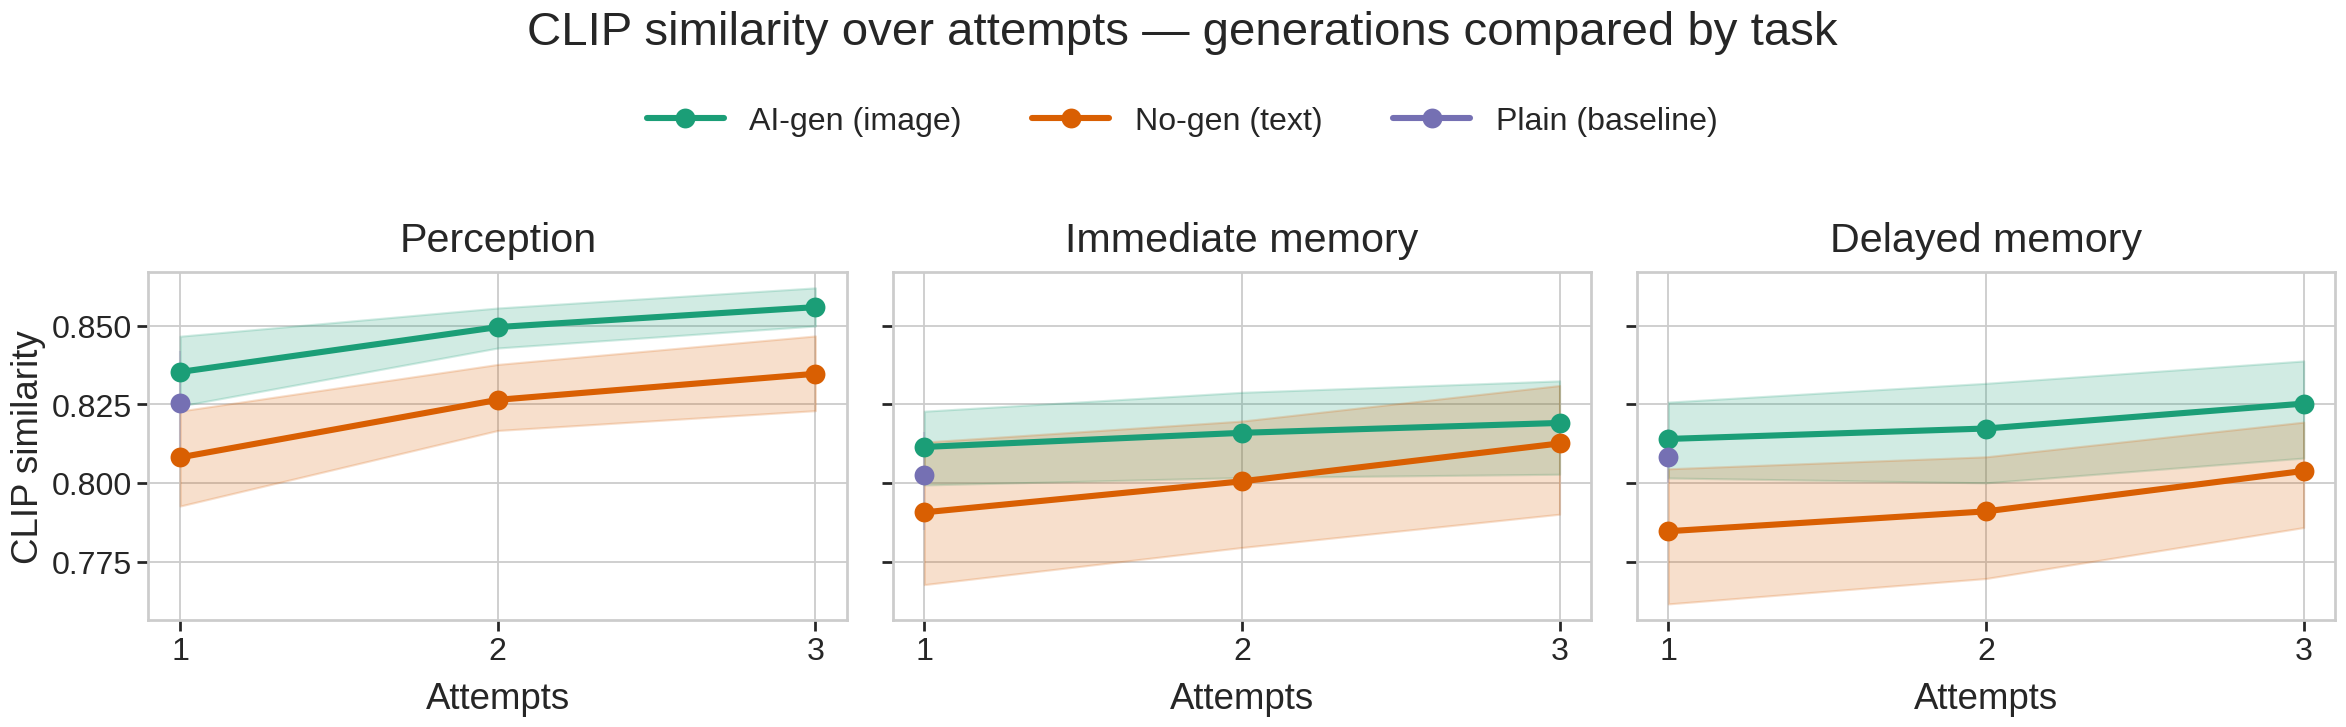

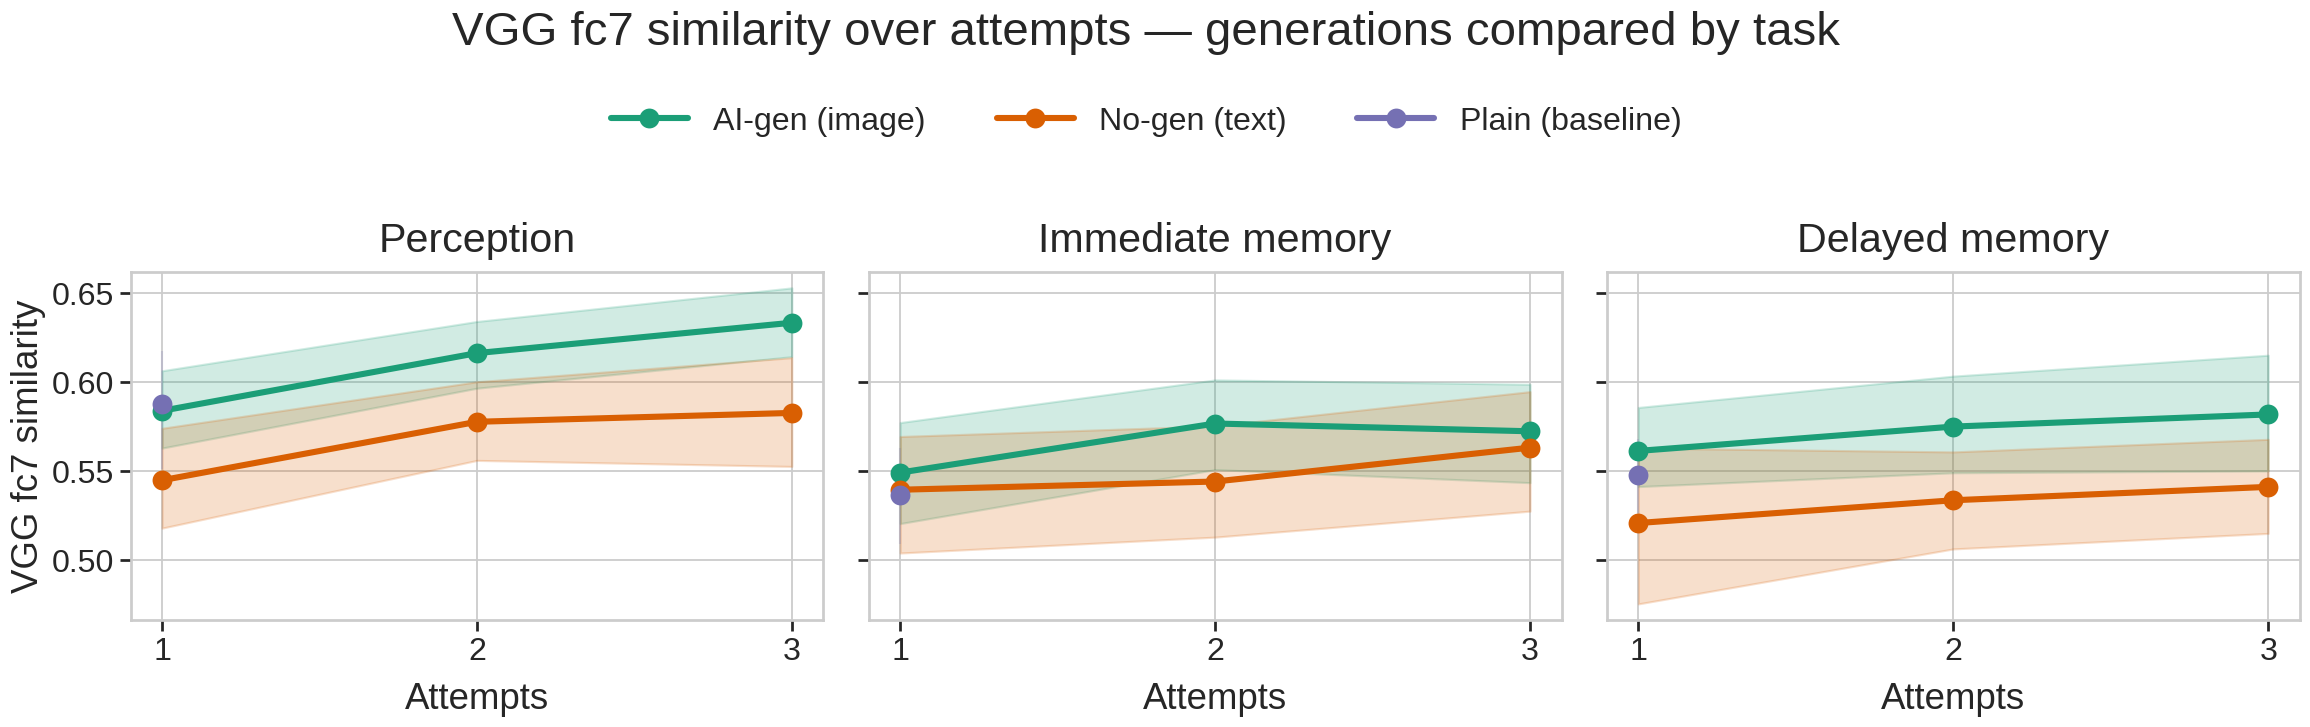

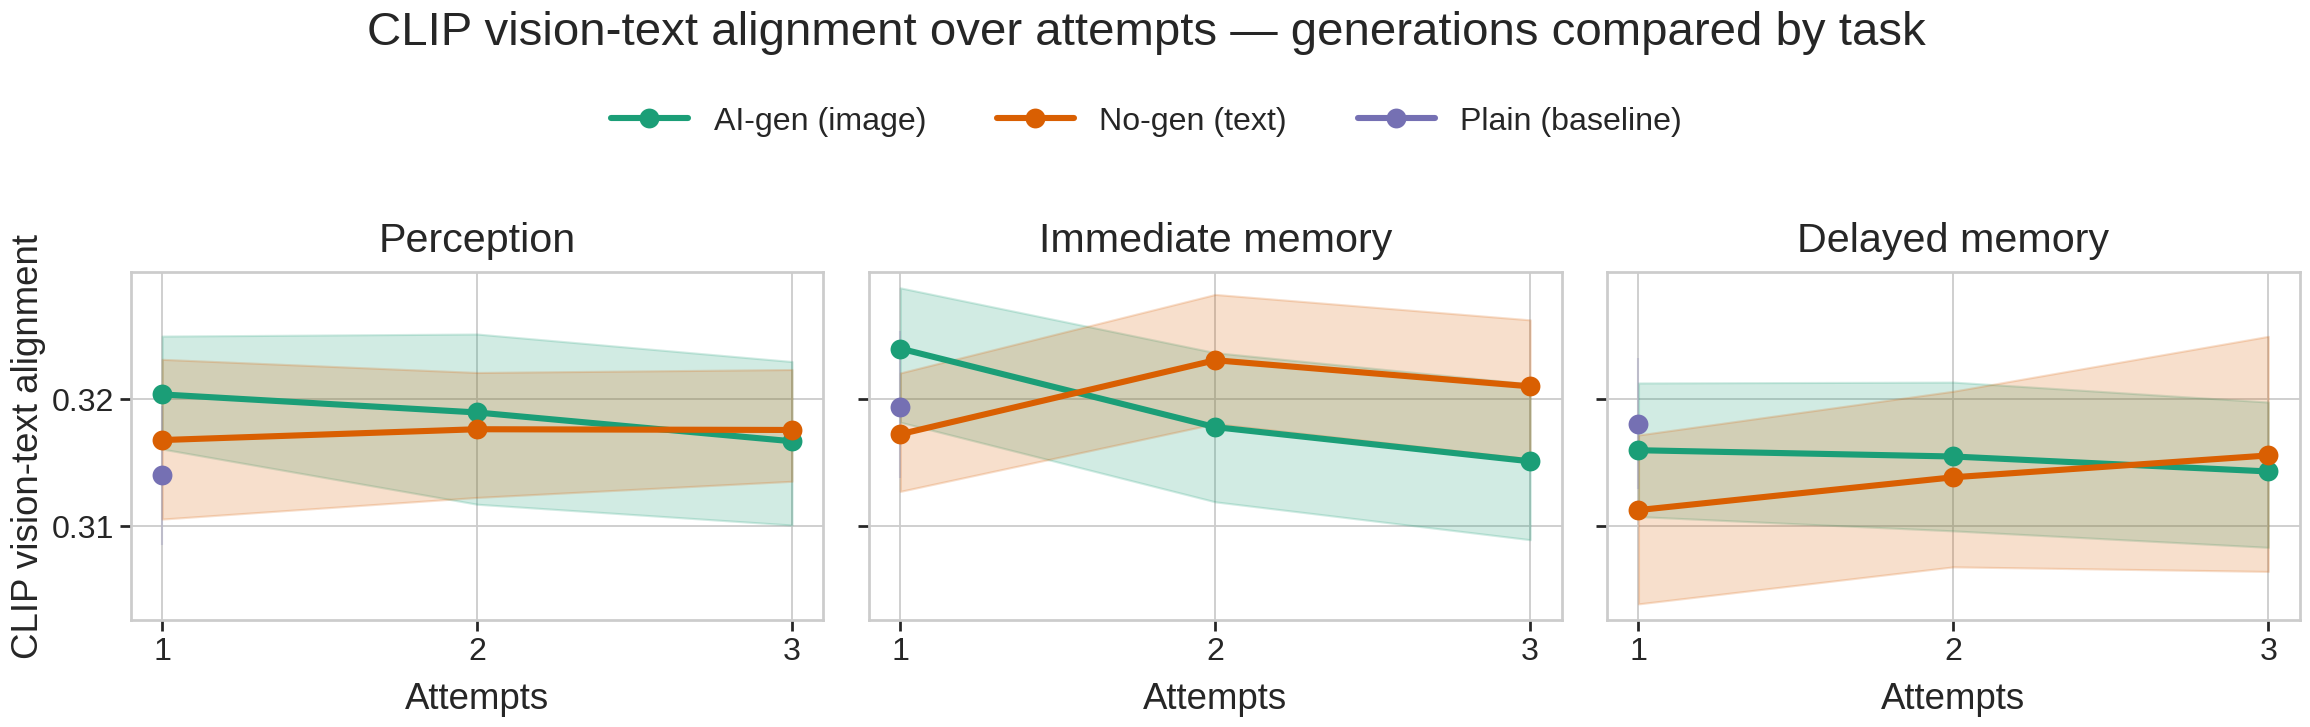

In [12]:
for metric, ylabel in SIM_METRICS.items():
    plot_generations_over_attempts_by_task(
        metric, ylabel, fname=f"crossgen_{metric}_over_attempts_by_task.png")

## Consecutive-attempt self-similarity
CLIP cosine similarity between a participant's gen image at attempt *n* and the previous
attempt (*n-1*), within the same target — a **refinement / convergence** measure rather than
distance to GT. One line per generation, faceted by task; attempt 1 has no predecessor so the
line starts at attempt 2.

*(Requires re-running `add_similarity_scores.py` so `clip_self_prev_similarity` is in the CSVs.)*

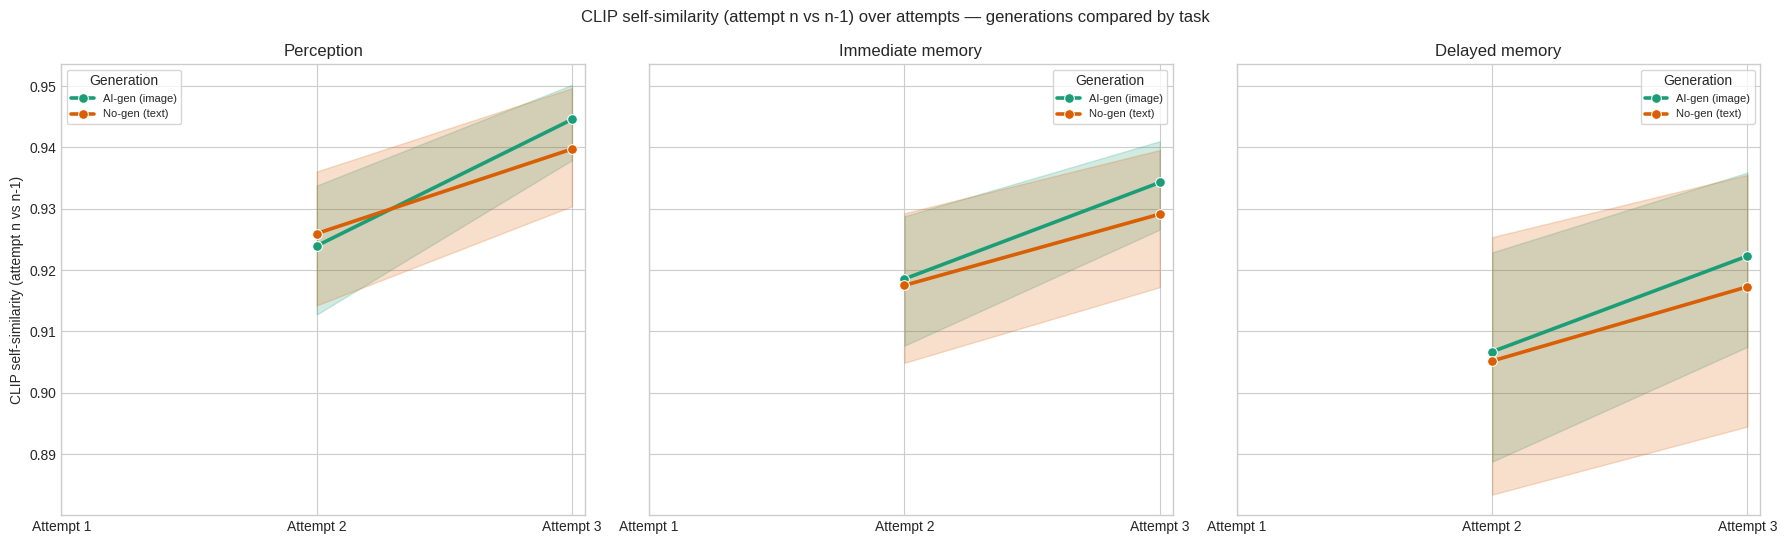

In [7]:
plot_generations_over_attempts_by_task(
    "clip_self_prev_similarity",
    "CLIP self-similarity (attempt n vs n-1)",
    fname="crossgen_clip_self_prev_similarity_over_attempts_by_task.png")

## Prompt length comparison
Do people write longer / more detailed prompts under one feedback type than another?
Same view as the similarity metrics (length over attempts, faceted by task), applied to `prompt_word_len` and CLIP `token_num`.

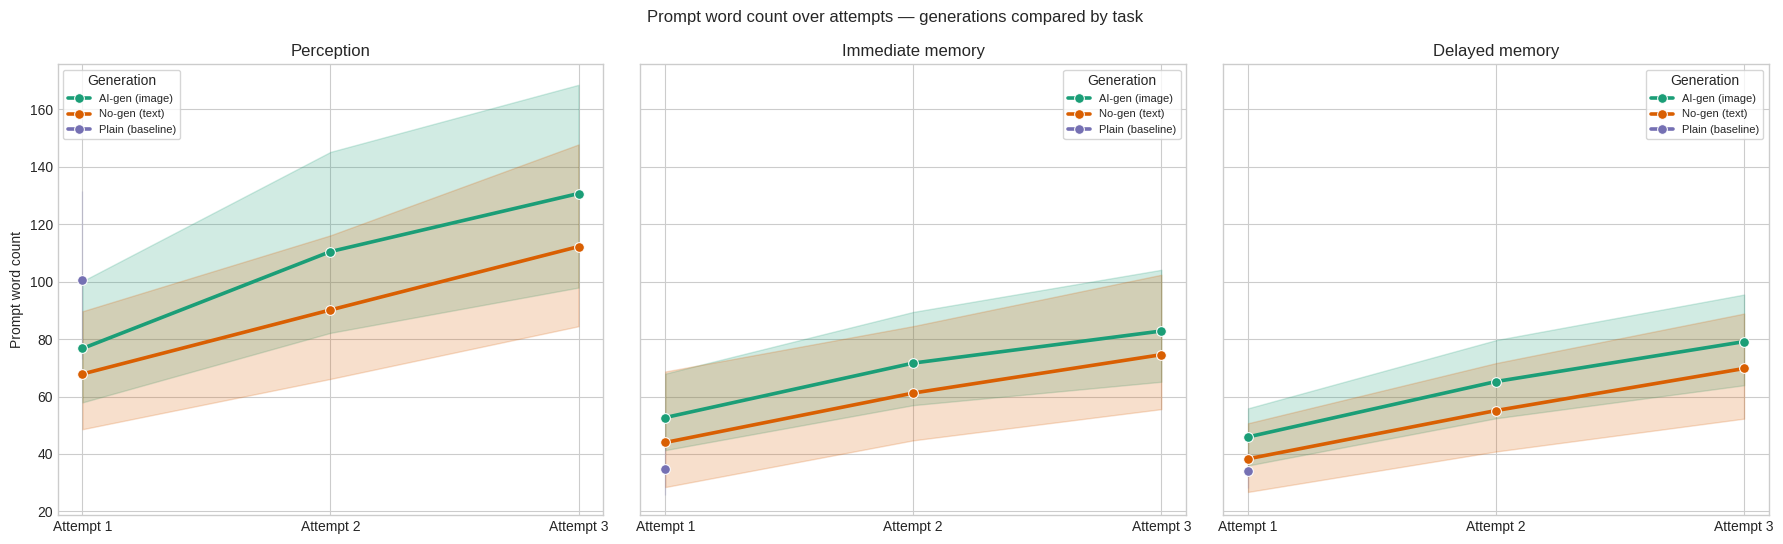

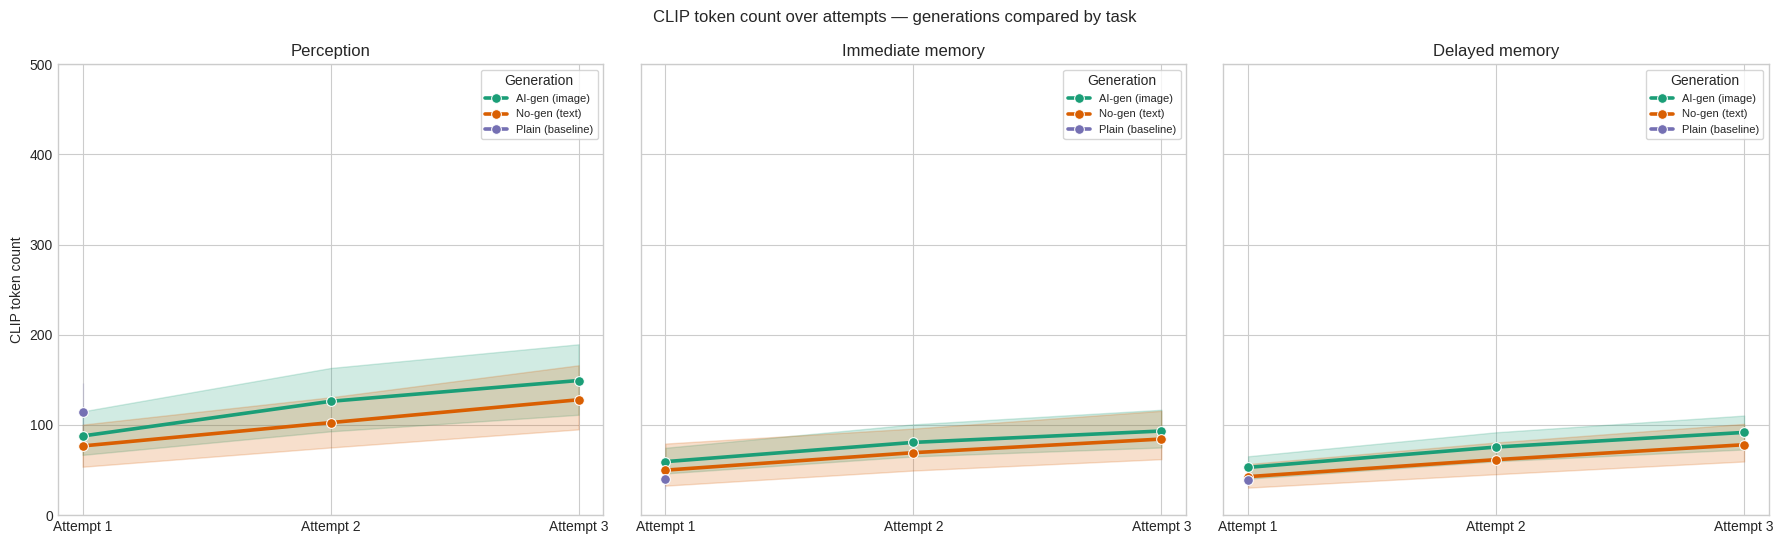

In [8]:
PROMPT_YLIM = {"prompt_word_len": None, "token_num": (0, 500)}  # adjust the token y-axis as you like
for metric, ylabel in PROMPT_METRICS.items():
    plot_generations_over_attempts_by_task(
        metric, ylabel, ylim=PROMPT_YLIM.get(metric),
        fname=f"crossgen_{metric}_over_attempts_by_task.png")


## Improvement delta (attempt 3 - attempt 1) by condition
How much does the feedback loop help, and does the benefit depend on the feedback / generation type? Per participant we take the mean at attempt 3 minus attempt 1 (positive = improved). Bars = mean +/- SE, x = task, color = generation, faint points = individual participants; the dashed line marks no change.

In [ ]:
def plot_improvement_delta_bars(metric, ylabel, data=None, fname=None):
    """Improvement delta = per-participant mean(attempt 3) - mean(attempt 1), one bar per
    (generation x task). x = task, hue/dodge = generation, faint per-participant points overlaid."""
    data = df_ppt if data is None else data
    pm = (data.groupby(["generation", "task", "uid", "attempt"], as_index=False)[metric].mean())
    wide = pm.pivot_table(index=["generation", "task", "uid"], columns="attempt", values=metric)
    if not {1, 3}.issubset(wide.columns):
        print(f"{metric}: missing attempt 1 or 3 - skipping")
        return
    wide = wide.dropna(subset=[1, 3])
    d = (wide[3] - wide[1]).rename("delta").reset_index()
    # Only legend generations that actually have a delta for this metric (e.g. subjective_score
    # exists for aigen only) — otherwise the legend shows empty color swatches.
    gens = [g for g in GEN_ORDER if g in set(d["generation"])]

    fig, ax = plt.subplots(figsize=(14.0, 8.0))
    sns.barplot(data=d, x="task", y="delta", hue="generation",
                order=TASK_ORDER, hue_order=gens,
                palette=GEN_COLORS, errorbar="se", capsize=0.08,
                err_kws={"linewidth": _lw(3.0), "color": "0.15"},
                edgecolor="0.15", linewidth=_lw(1.4), ax=ax)
    sns.stripplot(data=d, x="task", y="delta", hue="generation",
                  order=TASK_ORDER, hue_order=gens,
                  palette=GEN_COLORS, dodge=True, size=6, alpha=0.35,
                  linewidth=0, ax=ax, legend=False)
    ax.axhline(0, color="black", ls="--", lw=_lw(2.2))
    ax.set_xlabel(""); ax.set_ylabel(f"delta {ylabel}\n(attempt 3 - attempt 1)", labelpad=10)
    ax.set_xticks(range(len(TASK_ORDER)))
    ax.set_xticklabels([TASK_LABELS[t] for t in TASK_ORDER])
    ax.tick_params(width=_lw(1.8), length=7)
    handles, _ = ax.get_legend_handles_labels()
    if ax.get_legend() is not None:
        ax.get_legend().remove()  # replaced by the single figure-level legend
    fig.suptitle(f"Improvement in {ylabel} across attempts (participant means +/- SE)", y=0.99)
    fig.tight_layout(rect=[0, 0, 1, 0.88])
    _legend_above(fig, handles[:len(gens)], [GEN_LABELS[g] for g in gens], y=0.92)
    if fname:
        fig.savefig(GRAPHS / fname, dpi=300, bbox_inches="tight")
    plt.show()

for metric, ylabel in SIM_METRICS.items():
    plot_improvement_delta_bars(
        metric, ylabel, fname=f"crossgen_{metric}_improvement_delta.png")

---
### Adding `plain` later
Once `plain`'s `trials_final_sim.csv` exists, add `"plain"` to `GENS` (cell 3) and re-run.
`GEN_COLORS` / `GEN_LABELS` already include it, and `GEN_ORDER` picks up any generation that
actually loaded, so no plotting code changes are needed.